In [15]:
import pandas as pd

df = pd.read_parquet("data/data.parquet")

In [2]:
df.head(5)

,product_id,cluster_id,country_name,title,description,category_level_1_name,category_level_2_name,category_level_3_name,brand_name,url,shade_name,image_filename
0,f64ac32912c7e35c542f1a8283307f90626c4bd6f2ba90...,7315001,USA,Clean Matte BB Cream,Won't clog pores Lasts all day Oil free BB cream,MakeUp,Face,BB Cream,CoverGirl,https://www.walgreens.com/store/c/covergirl-cl...,Fair,f64ac32912c7e35c542f1a8283307f90626c4bd6f2ba90...
1,6a8468dff98b78f1dae63693580ec0320612b64dff010d...,10172001,USA,LOreal Paris Magic Skin Beautifier BB Cream - ...,"Discover the secret to flawless, even skin — i...",MakeUp,Face,BB Cream,L'Oréal Paris,https://www.target.com/p/l-39-oreal-paris-magi...,810 Fair,6a8468dff98b78f1dae63693580ec0320612b64dff010d...
2,a6f41f9cb717f3a113e353d19449db9980b657e426edb6...,10172001,USA,Magic Skin Beautifier BB Cream,"Discover the secret to flawless, even skin ton...",MakeUp,Face,BB Cream,L'Oréal Paris,https://www.walgreens.com/store/c/l'oreal-pari...,Fair,a6f41f9cb717f3a113e353d19449db9980b657e426edb6...
3,4a01eb7ffa3c09a6c9a7997ea509db95d3585ec449e675...,10172001,USA,"L'Oréal Paris Magic Skin Beautifier BB Cream, ...","Discover the secret to flawless, even skin ton...",MakeUp,Face,BB Cream,L'Oréal Paris,https://www.amazon.com/dp/B01MUCBM5W,Fair,4a01eb7ffa3c09a6c9a7997ea509db95d3585ec449e675...
4,f112ef392486ec9fda707499f13dbbeb619c07829af6d5...,10177001,USA,"LOreal Youth Code BB Cream Illuminator SPF 15,...",BB Cream,MakeUp,Face,BB Cream,L'Oréal Paris,https://www.amazon.com/dp/B008TFJGSA,Light,f112ef392486ec9fda707499f13dbbeb619c07829af6d5...


In [3]:
# dropping all rows with category level 2 who are not 'Hair Color' 
df_hair = df[(df['category_level_2_name'] == 'Hair Color')]
df_hair.head(5)

,product_id,cluster_id,country_name,title,description,category_level_1_name,category_level_2_name,category_level_3_name,brand_name,url,shade_name,image_filename
250,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...,11628001,USA,(3 pack) L'Oreal Paris Colorista Bleach Semi P...,L'Oreal Paris Colorista Bleach Semi Permanent ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Color...,Ombre,fd0cb918473a69efe320a494dea2d0f5fb73a1e3b9a2df...
251,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...,11630001,USA,L'Oreal Paris Feria Hyper Platinum Hair Color ...,L'Oreal Paris Feria Hyper Platinum Hair Color ...,Hair,Hair Color,Bleaching,L'Oréal Paris,https://www.walmart.com/ip/L-Oreal-Paris-Feria...,Hyper Platinum,eaa181c1a5498cb893e0af43d5b1d083c5875e19301e56...
252,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...,40660001,USA,"Complete Kit , Lightening Bleach",Ideal for dark hair Perfect for long or thick ...,Hair,Hair Color,Bleaching,Splat,https://www.walgreens.com/store/c/splat-comple...,Lightening Bleach,881f35f3121372b374c9edabaa4cf7ecceaa7120626962...
253,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...,40660001,USA,Splat Borderlands 3 Tyreen Blonde Lightening B...,"Sound your siren with icy blond hair, just lik...",Hair,Hair Color,Bleaching,Splat,https://www.walmart.com/ip/Splat-Borderlands-3...,Blonde,6de5723f8037d757e29d7a7e823d48909ecaa86ada2d17...
254,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...,40660001,USA,"Splat Lightening Bleach Kit, 4 oz.",Results depend on starting hair color and text...,Hair,Hair Color,Bleaching,Splat,https://www.amazon.com/dp/B0076OFKXK,Lightening Bleach,d53032be6d230d064c85aa4d68fd25109c0baa2f7b42b7...


In [4]:
df_hair.to_csv("data/hair_color_data.csv", index=False)

In [5]:
df_hair.count()

product_id               6172
cluster_id               6172
country_name             6172
title                    6172
description              5307
category_level_1_name    6172
category_level_2_name    6172
category_level_3_name    6172
brand_name               6172
url                      6172
shade_name               6172
image_filename           6172
dtype: int64

In [12]:
import cv2
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import os
from tqdm import tqdm

# On désactive les warnings de thread pour KMeans
os.environ["OMP_NUM_THREADS"] = "1"

def get_shade_and_centers(image_path, category_l3):
    """
    Extrait la couleur dominante et renvoie également tous les centres de clusters trouvés.
    Retourne: (best_rgb_list, all_centers_list_of_lists)
    """
    img = cv2.imread(image_path)
    # Important : retourner un tuple (None, None) pour maintenir la structure
    if img is None: return None, None
    
    # 1. Resize
    img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # 2. PARAMÈTRES
    s_min = 25 
    v_min = 60
    if category_l3 == 'Bleaching':
        s_min = 45 

    # 3. MASQUE
    mask = cv2.inRange(hsv, (0, s_min, v_min), (180, 255, 250))
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # 4. EXTRACTION
    valid_pixels = img_rgb[mask > 0]
    
    if len(valid_pixels) < 10:
        mask_rescue = cv2.inRange(hsv, (0, 10, 40), (180, 255, 250))
        valid_pixels = img_rgb[mask_rescue > 0]
        if len(valid_pixels) < 10:
            return None, None

    # 5. K-MEANS
    try:
        if len(valid_pixels) > 1000:
            indices = np.random.choice(len(valid_pixels), 1000, replace=False)
            pixels_to_cluster = valid_pixels[indices]
        else:
            pixels_to_cluster = valid_pixels

        kmeans = KMeans(n_clusters=3, n_init=3, random_state=42)
        kmeans.fit(pixels_to_cluster)
        centers = kmeans.cluster_centers_ # Ceci est un numpy array float
        
        # 6. SÉLECTION DU MEILLEUR (SATURATION)
        centers_hsv = cv2.cvtColor(np.uint8([centers]), cv2.COLOR_RGB2HSV)[0]
        best_idx = np.argmax(centers_hsv[:, 1])
        
        # Formatage pour la sortie
        best_rgb = centers[best_idx].astype(int).tolist()
        
        # On convertit TOUS les centres en liste d'entiers pour stockage facile (Parquet/JSON)
        all_centers = centers.astype(int).tolist()
        
        return best_rgb, all_centers
        
    except Exception as e:
        return None, None

# --- LANCEMENT FINAL ---
print("🚀 Démarrage de l'extraction étendue (RGB + Centers)...")

# On s'assure de travailler sur la copie
df_hair = df_hair.copy() 

tqdm.pandas()

# 1. On applique la fonction qui retourne un tuple
# On stocke temporairement dans une Series de tuples
temp_results = df_hair.progress_apply(
    lambda row: get_shade_and_centers(
        os.path.join("data","images", str(row['image_filename'])), 
        row['category_level_3_name']
    ), axis=1
)

# 2. On "dézippe" la Series de tuples en deux colonnes distinctes
# Si temp_results contient des (None, None), zip gère ça correctement
df_hair['rgb_extracted'], df_hair['kmeans_centers'] = zip(*temp_results)
# Statistiques de succès
success_count = df_hair['rgb_extracted'].notna().sum()
total = len(df_hair)
print(f"✅ Extraction terminée : {success_count}/{total} produits ({success_count/total:.1%})")

# Vérification visuelle rapide des premières lignes
print("\nExemple de données extraites :")
print(df_hair[['rgb_extracted', 'kmeans_centers']].head(3))

# Sauvegarde
df_hair.to_parquet("hair_products_final_colors.parquet")
print("💾 Fichier sauvegardé : hair_products_final_colors.parquet")

🚀 Démarrage de l'extraction étendue (RGB + Centers)...


100%|██████████| 6172/6172 [05:29<00:00, 18.75it/s] 


✅ Extraction terminée : 5927/6172 produits (96.0%)

Exemple de données extraites :
      rgb_extracted                                     kmeans_centers
250   [105, 73, 66]  [[248, 231, 199], [105, 73, 66], [169, 124, 107]]
251  [122, 83, 113]  [[122, 83, 113], [190, 150, 133], [233, 197, 1...
252   [112, 86, 66]  [[207, 174, 145], [112, 86, 66], [166, 133, 102]]
💾 Fichier sauvegardé : hair_products_final_colors.parquet


Image not found


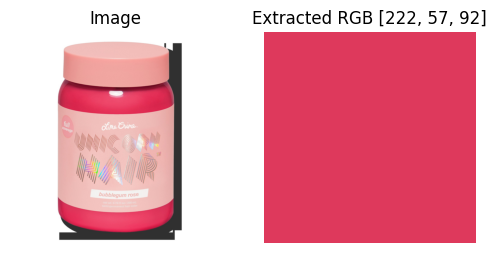

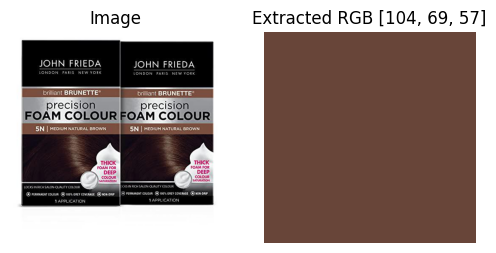

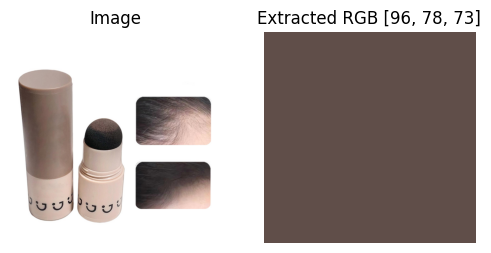

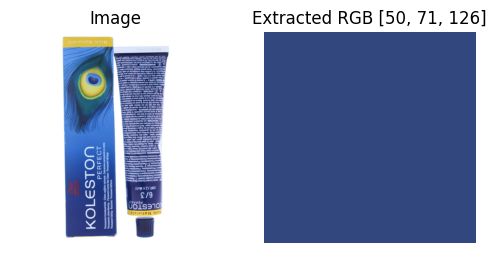

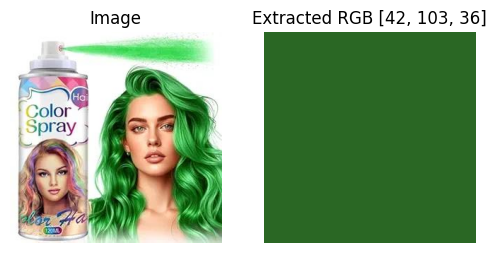

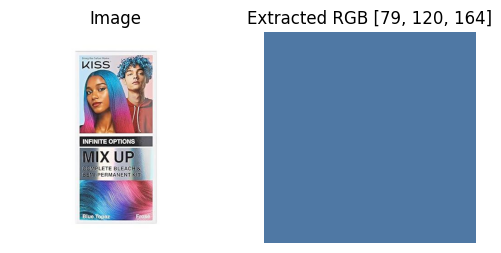

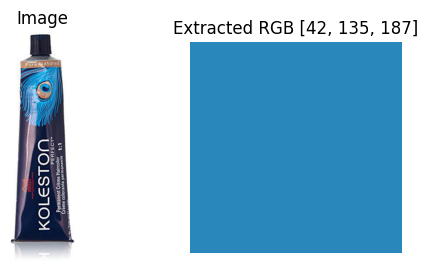

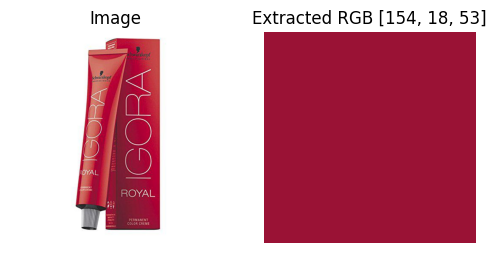

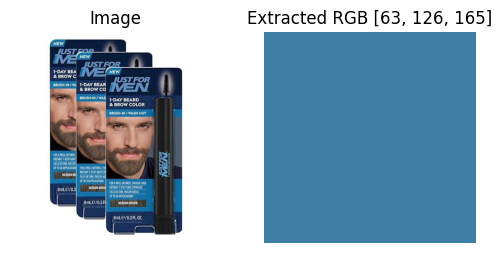

In [14]:
import cv2
import matplotlib.pyplot as plt

def show_result(row, image_dir="data/images"):
    img_path = os.path.join(image_dir, str(row["image_filename"]))
    img = cv2.imread(img_path)
    if img is None:
        print("Image not found")
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    color = row["rgb_extracted"]
    if color is None:
        print("No color extracted")
        return

    swatch = np.ones((100, 100, 3), dtype=np.uint8)
    swatch[:] = color

    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(img)
    ax[0].axis("off")
    ax[0].set_title("Image")

    ax[1].imshow(swatch)
    ax[1].axis("off")
    ax[1].set_title(f"Extracted RGB {color}")

    plt.show()

# Visualisation de quelques résultats aléatoires
for _, row in df_hair.sample(10).iterrows():
    show_result(row)